# 의왕시 교통안전 시각화 분석 (업데이트 반영)
최신 데이터 폴더(`데이터_정리`) 기준으로 로드/전처리와 시각화를 갱신했습니다.
- 셀 2: 데이터 로드/전처리
- 셀 3~7: 기존 시각화(최신 경로 반영)
- 셀 8~10: 신규 시각화(후보지 구성, 의왕 지표 비교, 데이터 정합성 요약)

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

# 가능한 경우 koreanize-matplotlib로 한글 폰트를 등록
try:
    import koreanize_matplotlib
    koreanize_matplotlib  # 폰트 등록용 import를 명시적으로 참조
except ImportError:
    pass

# --- 한글 폰트 설정 ---
def pick_korean_font():
    preferred = [
        'NanumBarunGothic',
        'NanumGothic',
        'Noto Sans CJK KR',
        'Noto Sans KR',
        'Malgun Gothic',
        'AppleGothic',
        'DejaVu Sans',
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in preferred:
        if name in available:
            return name
    return 'DejaVu Sans'

FONT_NAME = pick_korean_font()

sns.set_theme(
    style='whitegrid',
    rc={
        'font.family': FONT_NAME,
        'axes.unicode_minus': False,
        'figure.dpi': 120,
    },
)

def fix_korean_font(fig):
    for text_obj in fig.findobj(plt.Text):
        text_obj.set_fontfamily(FONT_NAME)

def resolve_base_dir():
    # Linux/Windows 어디서 실행해도 데이터 폴더를 찾도록 후보 경로를 순차 탐색
    candidates = [
        Path.cwd(),
        Path.cwd() / 'second report',
        Path.cwd().parent / 'second report',
        Path('/workspaces/qgis-second-report/second report'),
    ]
    for candidate in candidates:
        if (candidate / '데이터_정리').exists():
            return candidate
    raise FileNotFoundError('데이터_정리 폴더를 찾지 못했습니다. base 경로를 확인하세요.')

print('적용 폰트:', FONT_NAME)

base = resolve_base_dir()
data_root = base / '데이터_정리'
processed = data_root / '02_가공데이터'
qgis_csv = processed / 'qgis_ready' / 'csv'
cleaned = data_root / '03_정리데이터'

# 경기 시군구 사고/인구/세대/면적 통합 지표(정리본)
gyeonggi = pd.read_csv(cleaned / '09_경기_시군구별_교통사고_면적인구세대대비비율.csv', encoding='utf-8-sig')
gyeonggi = gyeonggi[gyeonggi['시도'] == '경기'].copy()
gyeonggi = gyeonggi[~gyeonggi['시군구'].astype(str).str.contains('합계', na=False)]
gyeonggi = gyeonggi.dropna(subset=['사고(건)']).copy()
uiwang_row = gyeonggi[gyeonggi['시군구'] == '의왕시'].copy()

# CCTV 개수/비율(정리본)
cctv_count = pd.read_csv(cleaned / '05_경기도_행정구역별_CCTV개수.csv', encoding='utf-8-sig')
cctv_count['CCTV개수'] = pd.to_numeric(cctv_count['CCTV개수'], errors='coerce')
cctv_ratio = pd.read_csv(cleaned / '06_경기도_지역별_면적인구세대대비_CCTV비율.csv', encoding='utf-8-sig')
for col in ['면적당_CCTV(대/㎢)', '인구1만명당_CCTV(대)']:
    cctv_ratio[col] = pd.to_numeric(cctv_ratio[col], errors='coerce')

# 사망교통사고(의왕시, 좌표 정리본)
fatal = pd.read_csv(qgis_csv / 'fatal_accidents_uiwang.csv', encoding='utf-8-sig')
fatal = fatal[fatal['시군명'] == '의왕시'].copy()
fatal['위도'] = pd.to_numeric(fatal['위도'], errors='coerce')
fatal['경도'] = pd.to_numeric(fatal['경도'], errors='coerce')
fatal = fatal.dropna(subset=['위도', '경도'])

# requirement 산출물(최신 가공 데이터)
traffic_cctv = pd.read_csv(processed / 'traffic_cctv_uiwang.csv', encoding='utf-8-sig')
hotspots = pd.read_csv(processed / 'accident_hotspots.csv', encoding='utf-8-sig')
bus_stop = pd.read_csv(processed / 'bus_stop_uiwang.csv', encoding='utf-8-sig')
candidates = pd.read_csv(processed / 'cctv_candidate_locations.csv', encoding='utf-8-sig')
comparison_summary = pd.read_csv(processed / 'comparison_summary_의왕_vs_CCTV교통단속.csv', encoding='utf-8-sig')
run_summary = pd.read_csv(processed / 'requirement_run_summary.csv', encoding='utf-8-sig')

# 숫자형 컬럼 정규화
for df_name, df_obj in [
    ('traffic_cctv', traffic_cctv),
    ('hotspots', hotspots),
    ('bus_stop', bus_stop),
    ('candidates', candidates),
]:
    if '위도' in df_obj.columns:
        df_obj['위도'] = pd.to_numeric(df_obj['위도'], errors='coerce')
    if '경도' in df_obj.columns:
        df_obj['경도'] = pd.to_numeric(df_obj['경도'], errors='coerce')

traffic_cctv = traffic_cctv.dropna(subset=['위도', '경도'])
hotspots = hotspots.dropna(subset=['위도', '경도'])
bus_stop = bus_stop.dropna(subset=['위도', '경도'])
candidates = candidates.dropna(subset=['위도', '경도'])

print('기준 경로:', base)
print('경기 시군구 수:', len(gyeonggi))
print('CCTV 개수 테이블 수:', len(cctv_count))
print('CCTV 비율 테이블 수:', len(cctv_ratio))
print('교통단속 CCTV 수:', len(traffic_cctv))
print('핫스팟 수:', len(hotspots))
print('의왕시 버스정류소 수:', len(bus_stop))
print('후보지 수:', len(candidates))

적용 폰트: NanumGothic
기준 경로: /workspaces/qgis-second-report/second report
경기 시군구 수: 31
CCTV 개수 테이블 수: 31
CCTV 비율 테이블 수: 31
교통단속 CCTV 수: 15
핫스팟 수: 66
의왕시 버스정류소 수: 389
후보지 수: 852


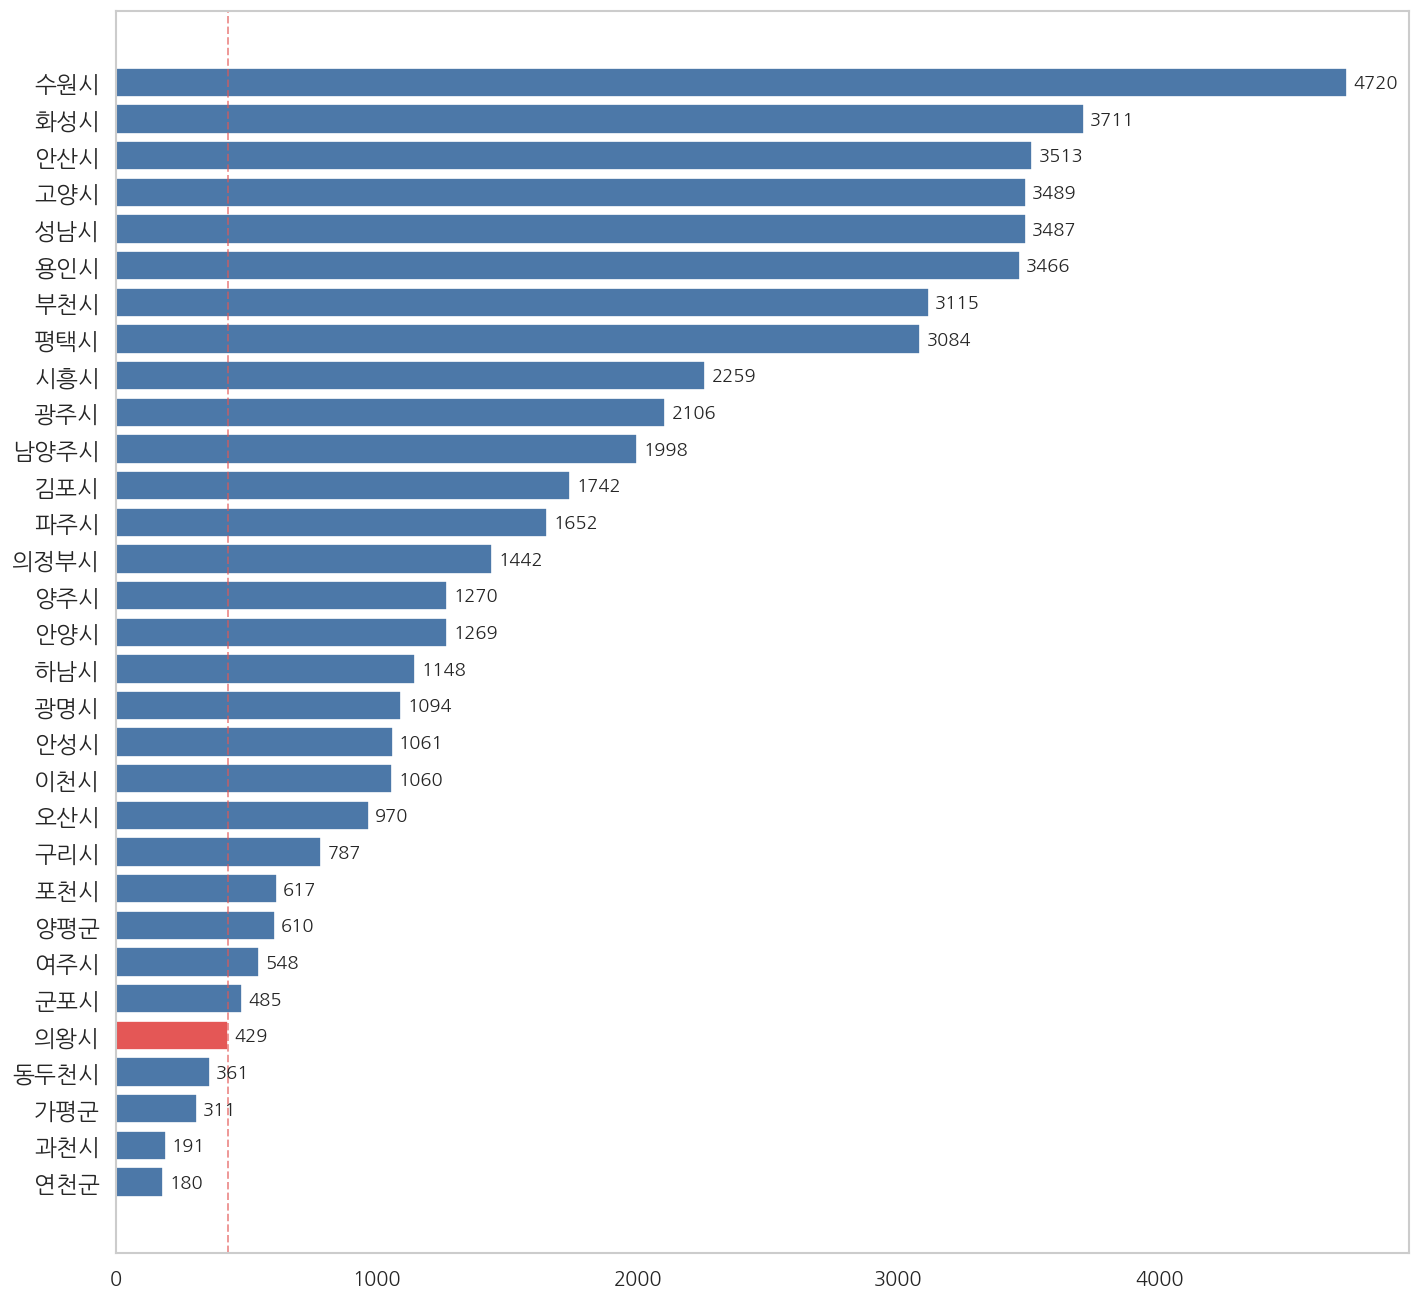

In [29]:
# 시각화 1-추가: 2024년 경기 전체 시군구 사고(건) 비교
all_compare = gyeonggi[['시군구', '사고(건)']].copy().sort_values('사고(건)', ascending=True)
all_compare['사고(건)'] = pd.to_numeric(all_compare['사고(건)'], errors='coerce')

bar_colors = ['#4C78A8' if name != '의왕시' else '#E45756' for name in all_compare['시군구']]

fig, ax = plt.subplots(figsize=(12, 11))
ax.barh(all_compare['시군구'], all_compare['사고(건)'], color=bar_colors)
# ax.set_title('2024년 경기 전체 시군구 사고(건) 비교', fontsize=16, fontweight='bold')
# ax.set_xlabel('사고(건)', fontsize=14)
# ax.set_ylabel('시군구', fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.grid(False)

uiwang_val = all_compare.loc[all_compare['시군구'] == '의왕시', '사고(건)']
if not uiwang_val.empty:
    ax.axvline(float(uiwang_val.iloc[0]), color='#E45756', linestyle='--', linewidth=1.2, alpha=0.6)

for y, val in enumerate(all_compare['사고(건)']):
    ax.text(val + all_compare['사고(건)'].max() * 0.005, y, f'{int(val)}', va='center', fontsize=11)

fix_korean_font(fig)
plt.tight_layout()
plt.show()

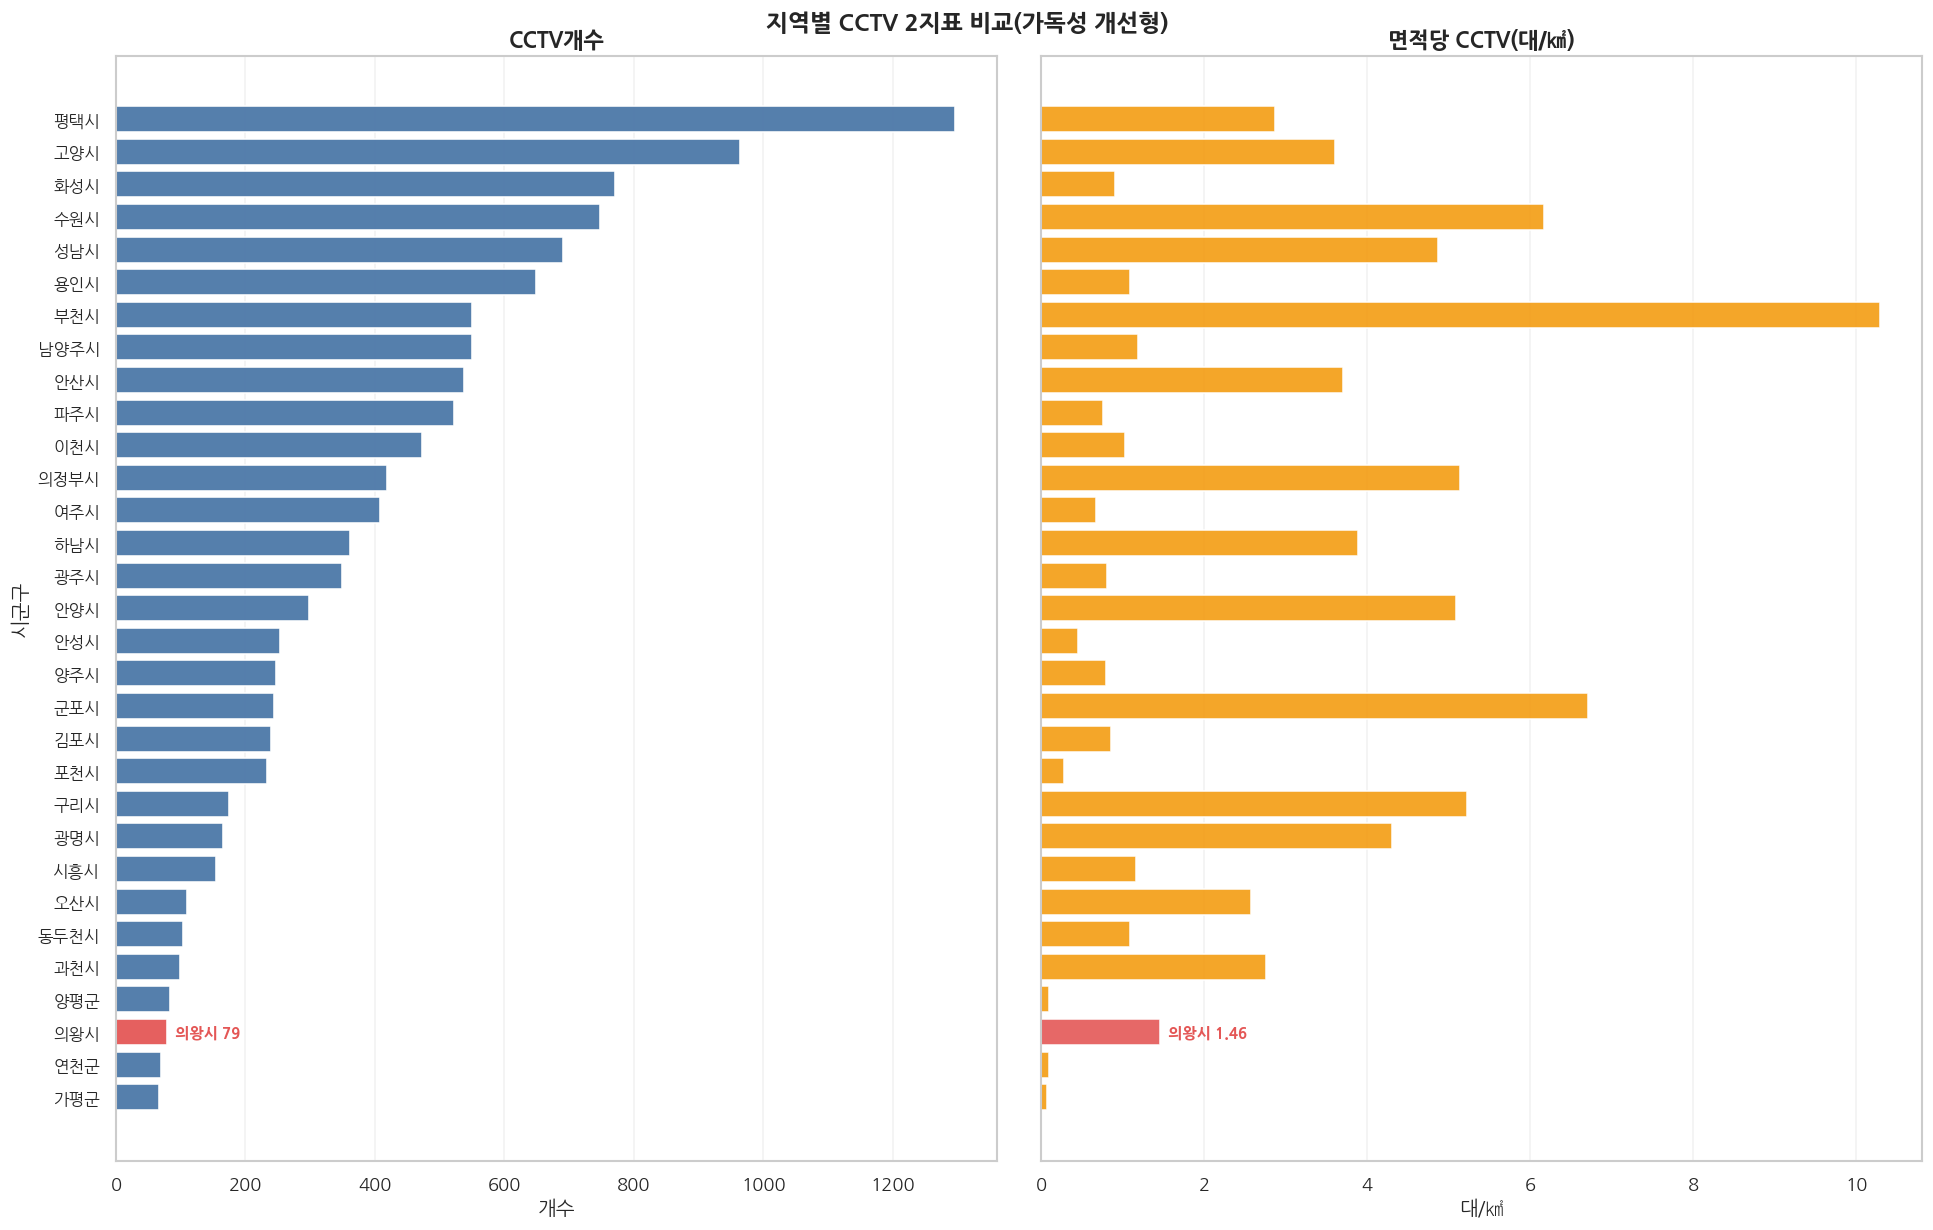

In [30]:
# 시각화 1-개선: 지역별 CCTV개수 + 면적당 CCTV(가로 2패널)
cctv_compare = cctv_count[['지역', 'CCTV개수']].dropna().copy()
area_ratio = cctv_ratio[['지역', '면적당_CCTV(대/㎢)']].dropna().copy()
merged = cctv_compare.merge(area_ratio, on='지역', how='inner')

merged['CCTV개수'] = pd.to_numeric(merged['CCTV개수'], errors='coerce')
merged['면적당_CCTV(대/㎢)'] = pd.to_numeric(merged['면적당_CCTV(대/㎢)'], errors='coerce')
merged = merged.dropna(subset=['CCTV개수', '면적당_CCTV(대/㎢)']).copy()
merged = merged.sort_values('CCTV개수', ascending=True).reset_index(drop=True)

if merged.empty:
    raise ValueError('시각화 대상 데이터가 비어 있습니다.')

plot_h = max(10, len(merged) * 0.28)
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, plot_h),
    sharey=True,
    constrained_layout=True,
    gridspec_kw={'wspace': 0.04},
)

is_uiwang = merged['지역'].eq('의왕시')
left_colors = np.where(is_uiwang, '#E45756', '#4C78A8')
right_colors = np.where(is_uiwang, '#E45756', '#F39C12')

axes[0].barh(merged['지역'], merged['CCTV개수'], color=left_colors, alpha=0.95)
axes[1].barh(merged['지역'], merged['면적당_CCTV(대/㎢)'], color=right_colors, alpha=0.9)

axes[0].set_title('CCTV개수', fontsize=13, fontweight='bold')
axes[1].set_title('면적당 CCTV(대/㎢)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('개수')
axes[1].set_xlabel('대/㎢')
axes[0].set_ylabel('시군구')
axes[1].set_ylabel('')

for ax in axes:
    ax.grid(axis='x', alpha=0.25)
    ax.grid(axis='y', alpha=0)
    ax.tick_params(axis='y', labelsize=10)

if is_uiwang.any():
    city = '의왕시'
    v1 = float(merged.loc[is_uiwang, 'CCTV개수'].iloc[0])
    v2 = float(merged.loc[is_uiwang, '면적당_CCTV(대/㎢)'].iloc[0])
    axes[0].text(v1, city, f'  의왕시 {int(v1)}', va='center', color='#E45756', fontsize=9, fontweight='bold')
    axes[1].text(v2, city, f'  의왕시 {v2:.2f}', va='center', color='#E45756', fontsize=9, fontweight='bold')

fig.suptitle('지역별 CCTV 2지표 비교(가독성 개선형)', y=1.01, fontsize=14, fontweight='bold')
fix_korean_font(fig)
plt.show()

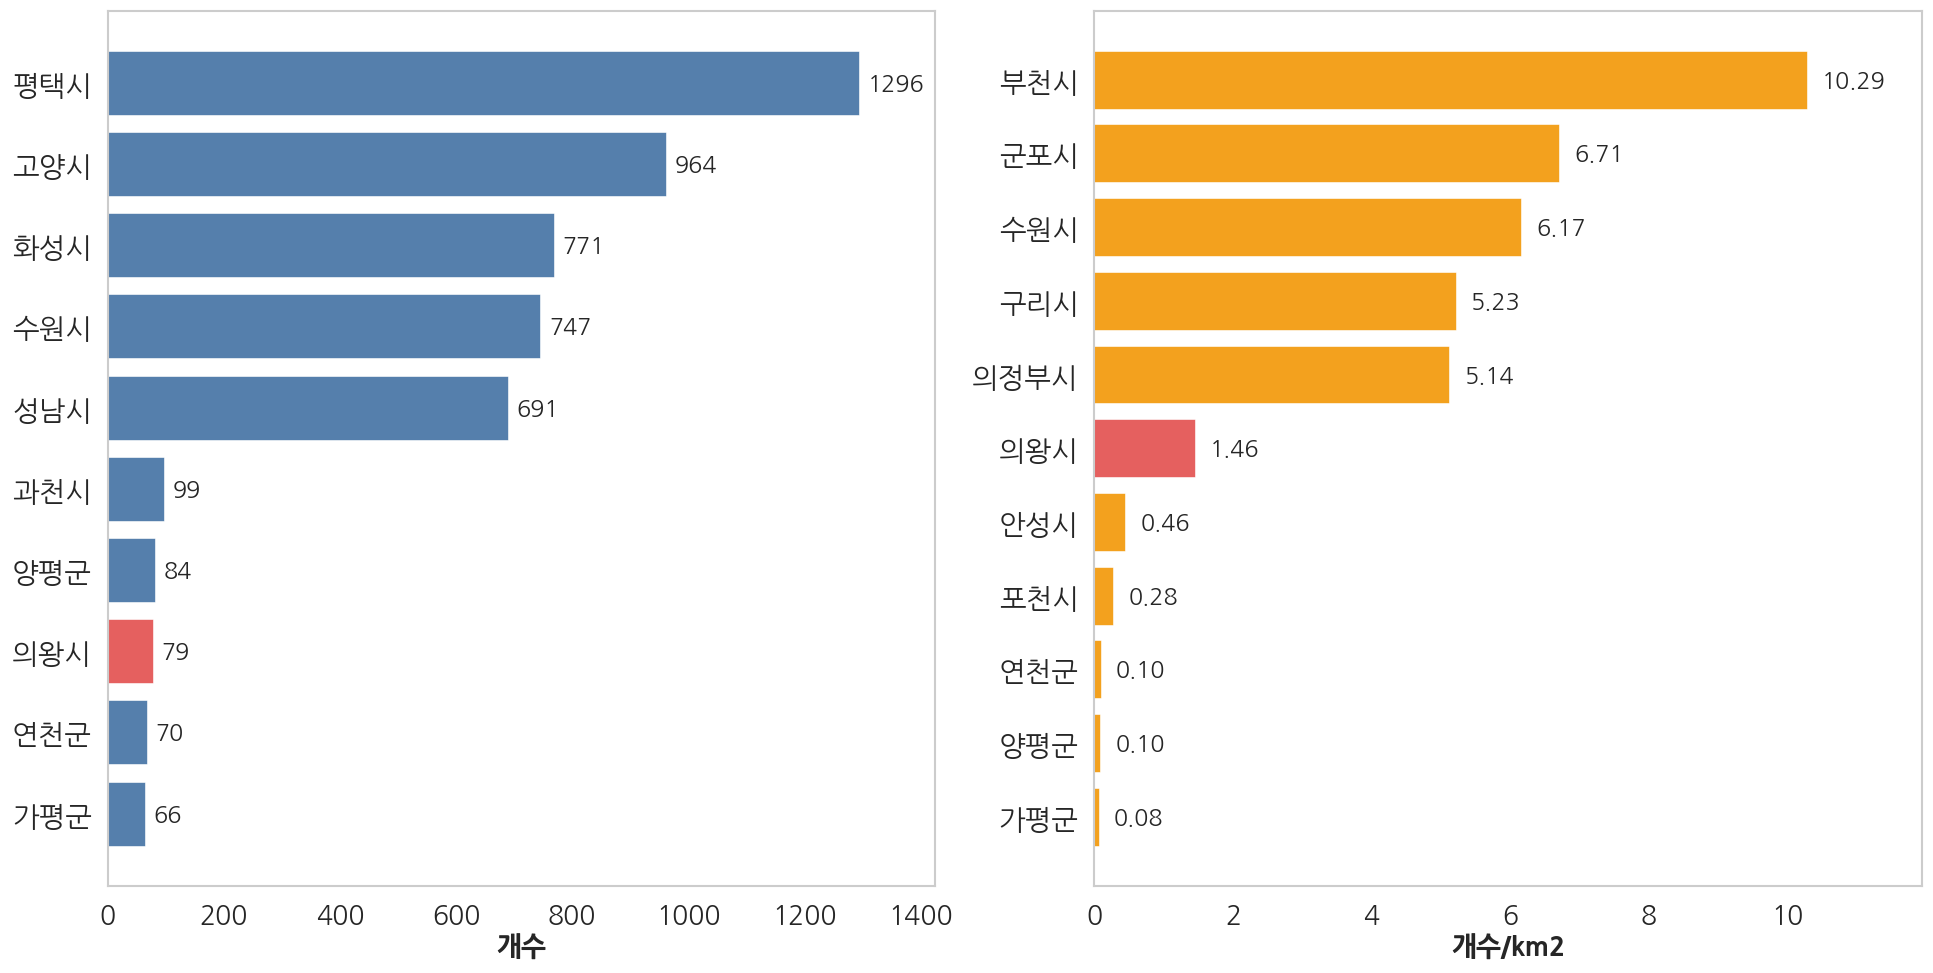

In [31]:
# 시각화 1-대안 A 확정: 상위 5개 + 하위 5개 + 의왕시
metric_count = 'CCTV개수'
metric_area = '면적당_CCTV(대/㎢)'

if 'merged' not in globals() or merged.empty:
    raise ValueError('먼저 4번 셀을 실행해 merged 데이터를 준비하세요.')

base_df = merged.copy()

def pick_top_bottom_with_city(df, value_col, city_col='지역', n=5, target_city='의왕시'):
    top = df.nlargest(n, value_col).copy()
    bottom = df.nsmallest(n, value_col).copy()
    target = df[df[city_col] == target_city].copy()
    picked = pd.concat([top, bottom, target], ignore_index=True)
    picked = picked.drop_duplicates(subset=city_col)
    return picked.sort_values(value_col, ascending=True).reset_index(drop=True)

plot_count = pick_top_bottom_with_city(base_df, metric_count, n=5)
plot_area = pick_top_bottom_with_city(base_df, metric_area, n=5)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)
colors_count = np.where(plot_count['지역'].eq('의왕시'), '#E45756', '#4C78A8')
colors_area = np.where(plot_area['지역'].eq('의왕시'), '#E45756', '#F39C12')

axes[0].barh(plot_count['지역'], plot_count[metric_count], color=colors_count, alpha=0.95)
axes[1].barh(plot_area['지역'], plot_area[metric_area], color=colors_area, alpha=0.95)

axes[0].set_xlabel('개수', fontsize=16, fontweight='bold')
axes[1].set_xlabel('개수/km2', fontsize=16, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=17)
axes[1].tick_params(axis='y', labelsize=17)
axes[0].tick_params(axis='x', labelsize=16)
axes[1].tick_params(axis='x', labelsize=16)

for ax in axes:
    ax.grid(axis='x', alpha=0)
    ax.grid(axis='y', alpha=0)

count_max = float(plot_count[metric_count].max())
area_max = float(plot_area[metric_area].max())
axes[0].set_xlim(0, count_max * 1.10)
axes[1].set_xlim(0, area_max * 1.16)
count_offset = count_max * 0.01
area_offset = area_max * 0.02

for y, val in enumerate(plot_count[metric_count]):
    x_text = min(val + count_offset, axes[0].get_xlim()[1] - count_offset * 1.6)
    axes[0].text(x_text, y, f'{int(val)}', va='center', ha='left', fontsize=14, clip_on=True)
for y, val in enumerate(plot_area[metric_area]):
    x_text = min(val + area_offset, axes[1].get_xlim()[1] - area_offset * 1.6)
    axes[1].text(x_text, y, f'{val:.2f}', va='center', ha='left', fontsize=14, clip_on=True)

fix_korean_font(fig)
plt.show()

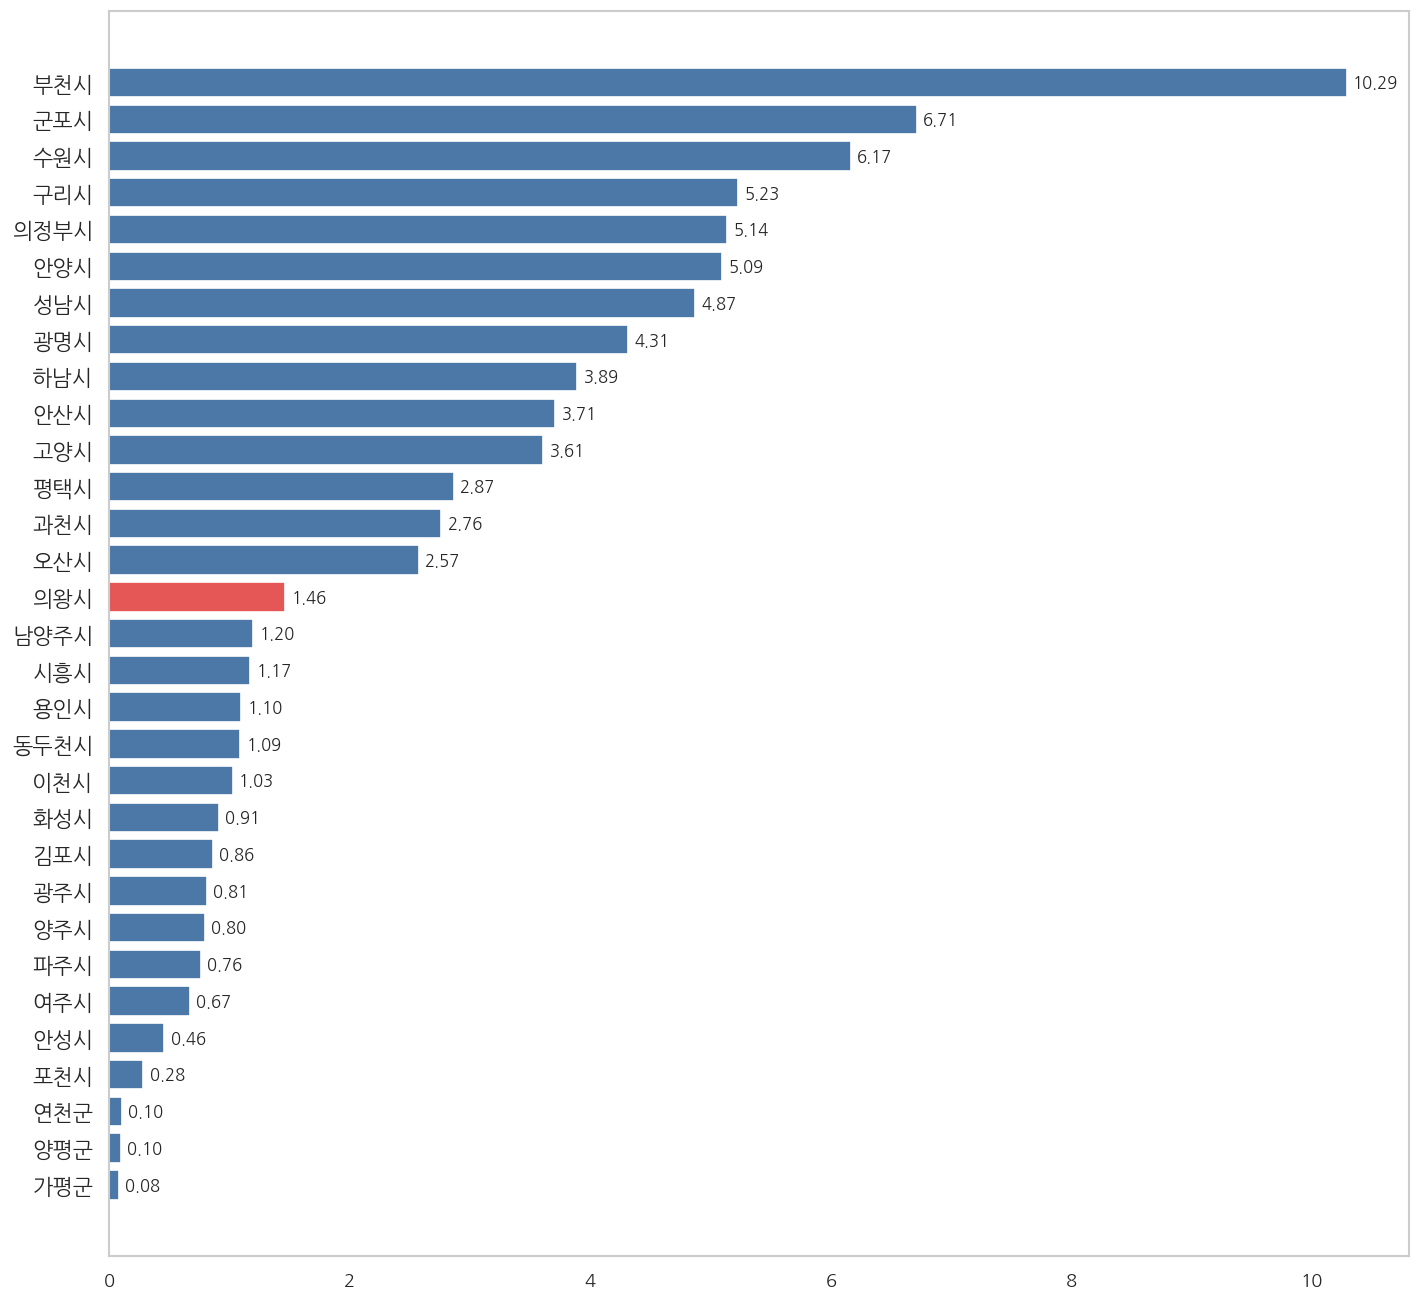

In [32]:
# 시각화 1-확장A: 경기 시군구 면적당 CCTV(대/㎢) 순위
rank_area_cctv = cctv_ratio[['지역', '면적당_CCTV(대/㎢)']].dropna().copy()
rank_area_cctv = rank_area_cctv.sort_values('면적당_CCTV(대/㎢)', ascending=True)

colors = ['#4C78A8' if x != '의왕시' else '#E45756' for x in rank_area_cctv['지역']]

fig, ax = plt.subplots(figsize=(12, 11))
ax.barh(rank_area_cctv['지역'], rank_area_cctv['면적당_CCTV(대/㎢)'], color=colors)
# ax.set_title('경기 시군구 면적당 CCTV(대/㎢) 순위', fontsize=15, fontweight='bold')
# ax.set_xlabel('면적당 CCTV(대/㎢)', fontsize=13)
# ax.set_ylabel('시군구', fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=11)
ax.grid(False)

for y, val in enumerate(rank_area_cctv['면적당_CCTV(대/㎢)']):
    ax.text(val + rank_area_cctv['면적당_CCTV(대/㎢)'].max() * 0.005, y, f'{val:.2f}', va='center', fontsize=10)

fix_korean_font(fig)
plt.tight_layout()
plt.show()

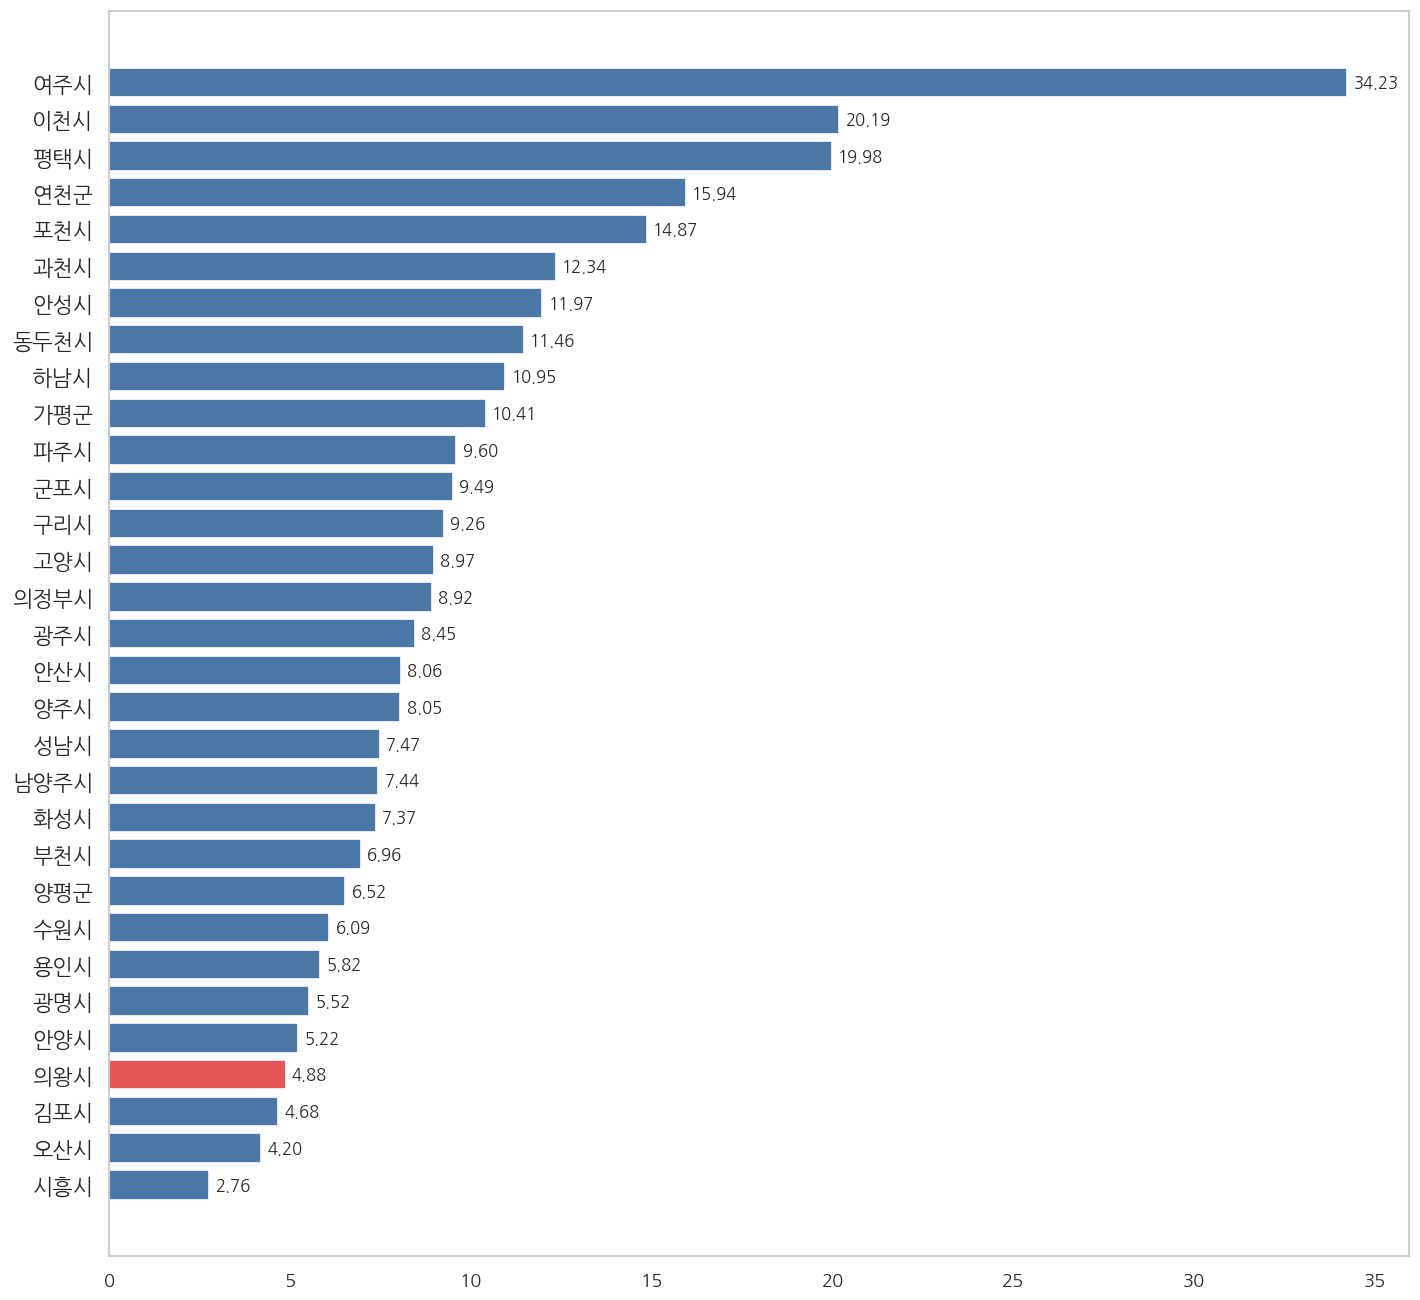

In [33]:
# 시각화 1-확장B: 경기 시군구 인구 1만명당 CCTV(대) 순위
rank_pop_cctv = cctv_ratio[['지역', '인구1만명당_CCTV(대)']].dropna().copy()
rank_pop_cctv = rank_pop_cctv.sort_values('인구1만명당_CCTV(대)', ascending=True)

colors = ['#4C78A8' if x != '의왕시' else '#E45756' for x in rank_pop_cctv['지역']]

fig, ax = plt.subplots(figsize=(12, 11))
ax.barh(rank_pop_cctv['지역'], rank_pop_cctv['인구1만명당_CCTV(대)'], color=colors)
# ax.set_title('경기 시군구 인구 1만명당 CCTV(대) 순위', fontsize=15, fontweight='bold')
# ax.set_xlabel('인구 1만명당 CCTV(대)', fontsize=13)
# ax.set_ylabel('시군구', fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=11)
ax.grid(False)

for y, val in enumerate(rank_pop_cctv['인구1만명당_CCTV(대)']):
    ax.text(val + rank_pop_cctv['인구1만명당_CCTV(대)'].max() * 0.005, y, f'{val:.2f}', va='center', fontsize=10)

fix_korean_font(fig)
plt.tight_layout()
plt.show()

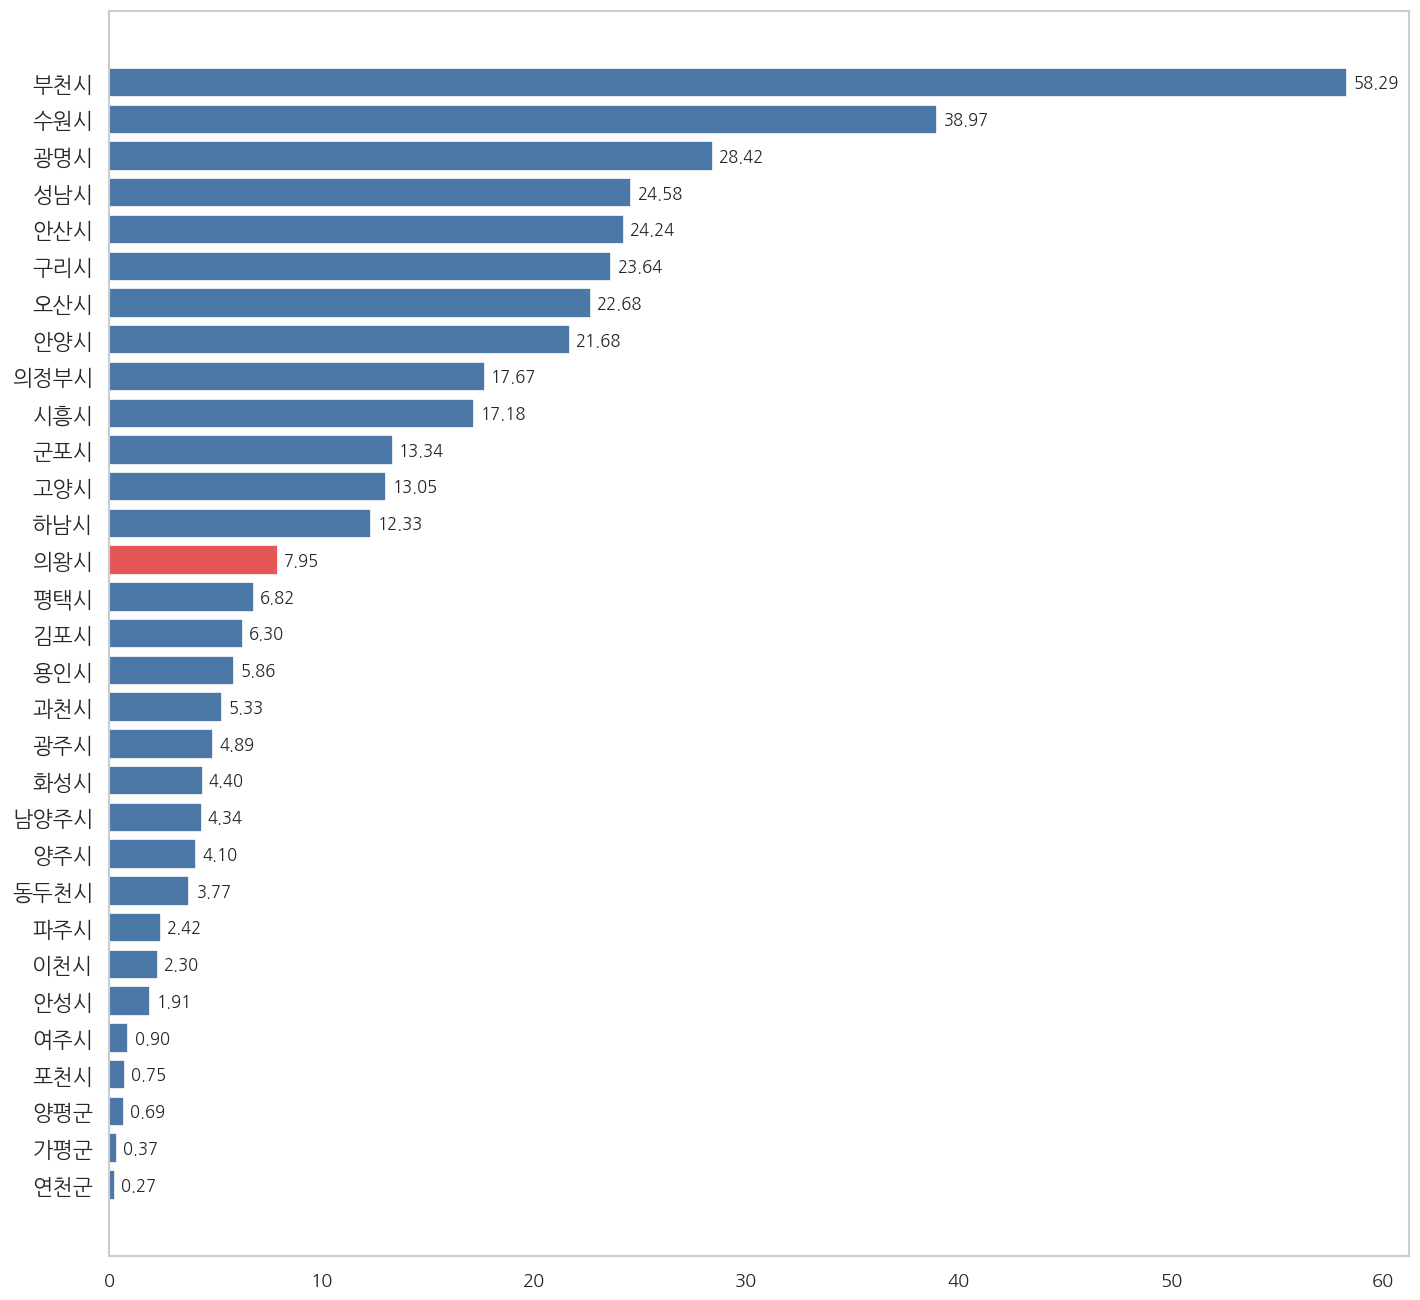

In [34]:
# 시각화 1-확장C: 경기 시군구 면적대비 사고(건/㎢) 순위
rank_area_acc = gyeonggi[['시군구', '사고_면적대비(건/㎢)']].dropna().copy()
rank_area_acc = rank_area_acc.sort_values('사고_면적대비(건/㎢)', ascending=True)

colors = ['#4C78A8' if x != '의왕시' else '#E45756' for x in rank_area_acc['시군구']]

fig, ax = plt.subplots(figsize=(12, 11))
ax.barh(rank_area_acc['시군구'], rank_area_acc['사고_면적대비(건/㎢)'], color=colors)
# ax.set_title('경기 시군구 면적대비 사고(건/㎢) 순위', fontsize=15, fontweight='bold')
# ax.set_xlabel('사고(건/㎢)', fontsize=13)
# ax.set_ylabel('시군구', fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=11)
ax.grid(False)

for y, val in enumerate(rank_area_acc['사고_면적대비(건/㎢)']):
    ax.text(val + rank_area_acc['사고_면적대비(건/㎢)'].max() * 0.005, y, f'{val:.2f}', va='center', fontsize=10)

fix_korean_font(fig)
plt.tight_layout()
plt.show()

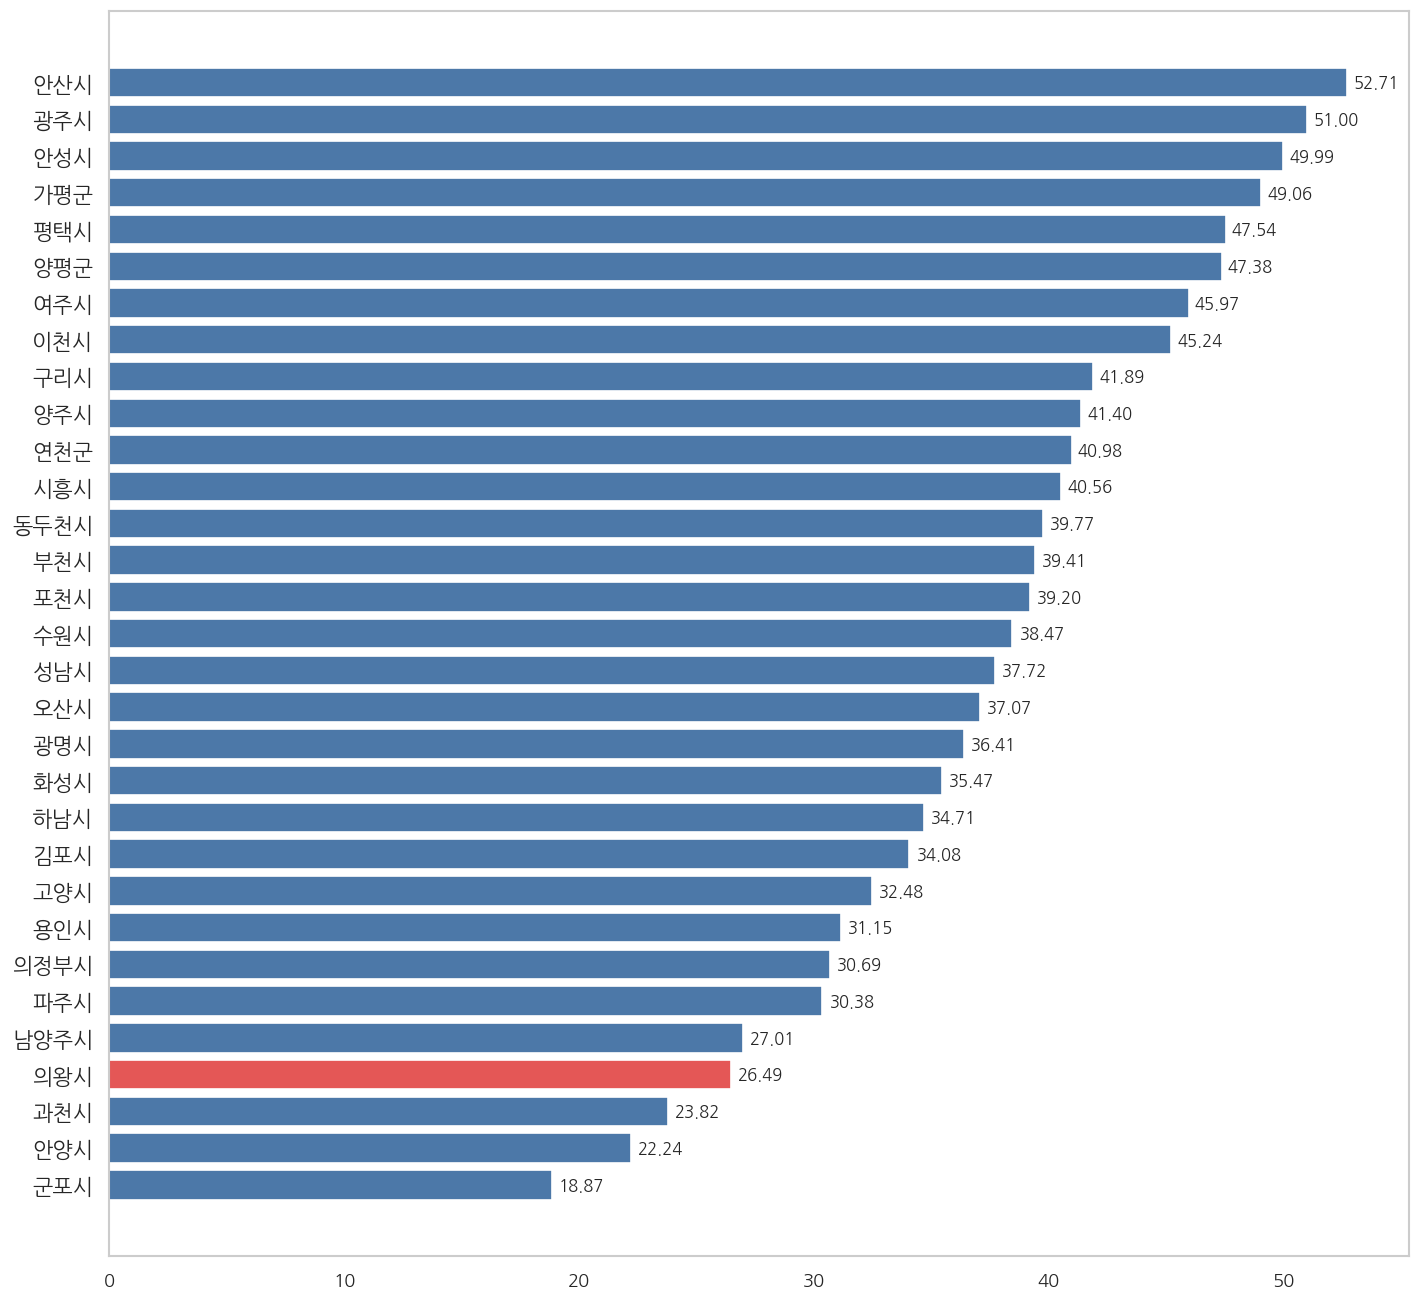

In [35]:
# 시각화 1-확장D: 경기 시군구 인구 1만명당 사고(건) 순위
rank_pop_acc = gyeonggi[['시군구', '사고_인구1만명당(건)']].dropna().copy()
rank_pop_acc = rank_pop_acc.sort_values('사고_인구1만명당(건)', ascending=True)

colors = ['#4C78A8' if x != '의왕시' else '#E45756' for x in rank_pop_acc['시군구']]

fig, ax = plt.subplots(figsize=(12, 11))
ax.barh(rank_pop_acc['시군구'], rank_pop_acc['사고_인구1만명당(건)'], color=colors)
# ax.set_title('경기 시군구 인구 1만명당 사고(건) 순위', fontsize=15, fontweight='bold')
# ax.set_xlabel('인구 1만명당 사고(건)', fontsize=13)
# ax.set_ylabel('시군구', fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=11)
ax.grid(False)

for y, val in enumerate(rank_pop_acc['사고_인구1만명당(건)']):
    ax.text(val + rank_pop_acc['사고_인구1만명당(건)'].max() * 0.005, y, f'{val:.2f}', va='center', fontsize=10)

fix_korean_font(fig)
plt.tight_layout()
plt.show()

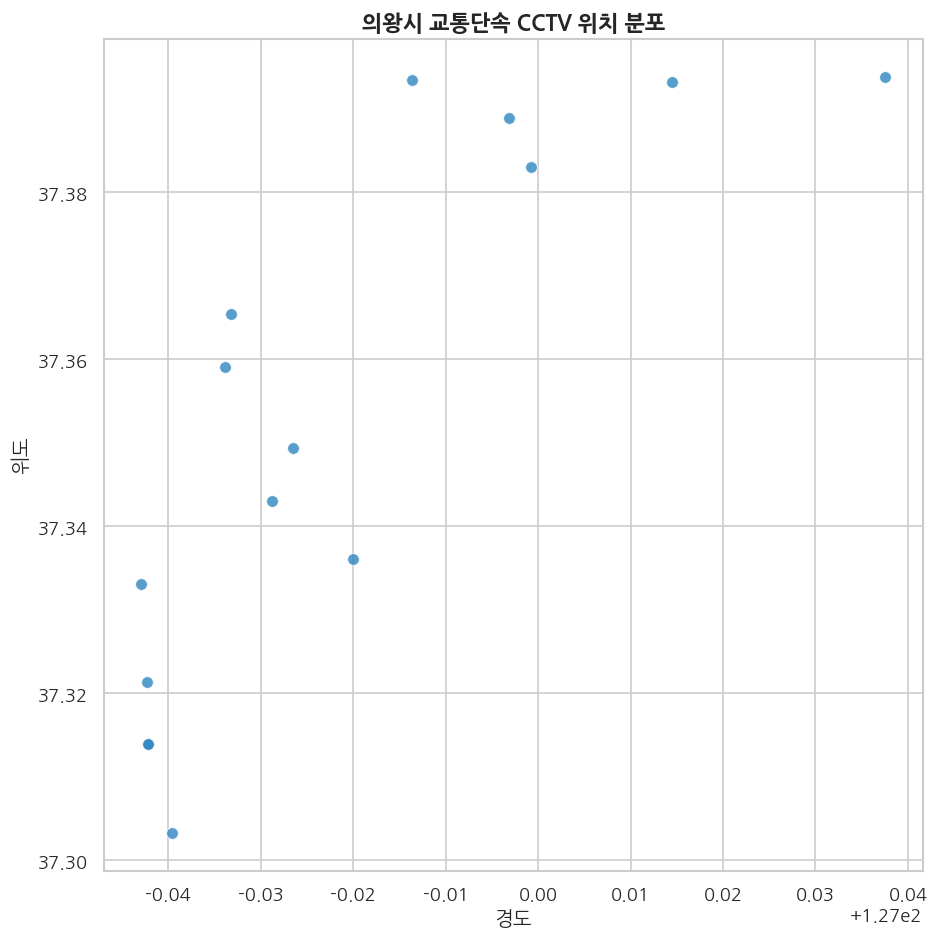

In [36]:
# 시각화 2: 교통단속 CCTV 위치 분포
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=traffic_cctv,
    x='경도',
    y='위도',
    s=50,
    alpha=0.8,
    color='#2E86C1',
    ax=ax
)
ax.set_title('의왕시 교통단속 CCTV 위치 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
fix_korean_font(fig)
plt.tight_layout()
plt.show()

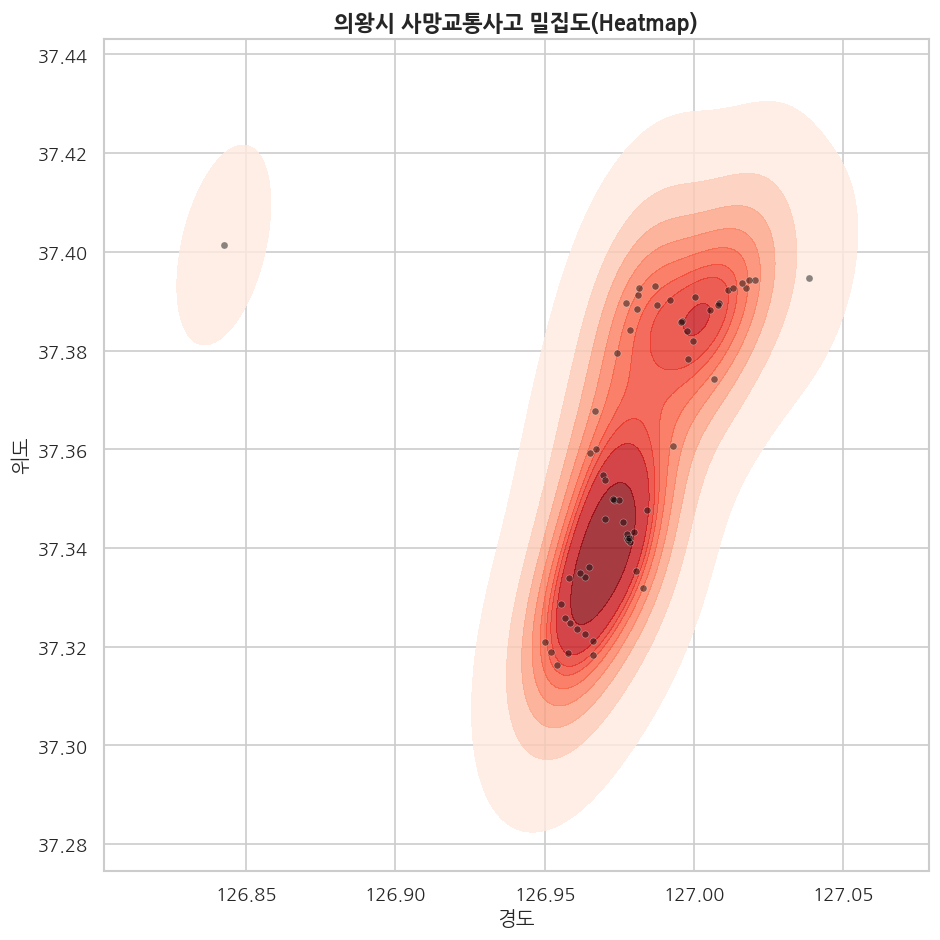

In [37]:
# 시각화 3: 의왕시 사망교통사고 밀집도(Heatmap)
fig, ax = plt.subplots(figsize=(8, 8))
sns.kdeplot(
    data=fatal,
    x='경도',
    y='위도',
    fill=True,
    cmap='Reds',
    levels=10,
    thresh=0.02,
    alpha=0.8,
    ax=ax
)
sns.scatterplot(
    data=fatal,
    x='경도',
    y='위도',
    s=18,
    color='black',
    alpha=0.45,
    ax=ax
)
ax.set_title('의왕시 사망교통사고 밀집도(Heatmap)', fontsize=13, fontweight='bold')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
fix_korean_font(fig)
plt.tight_layout()
plt.show()

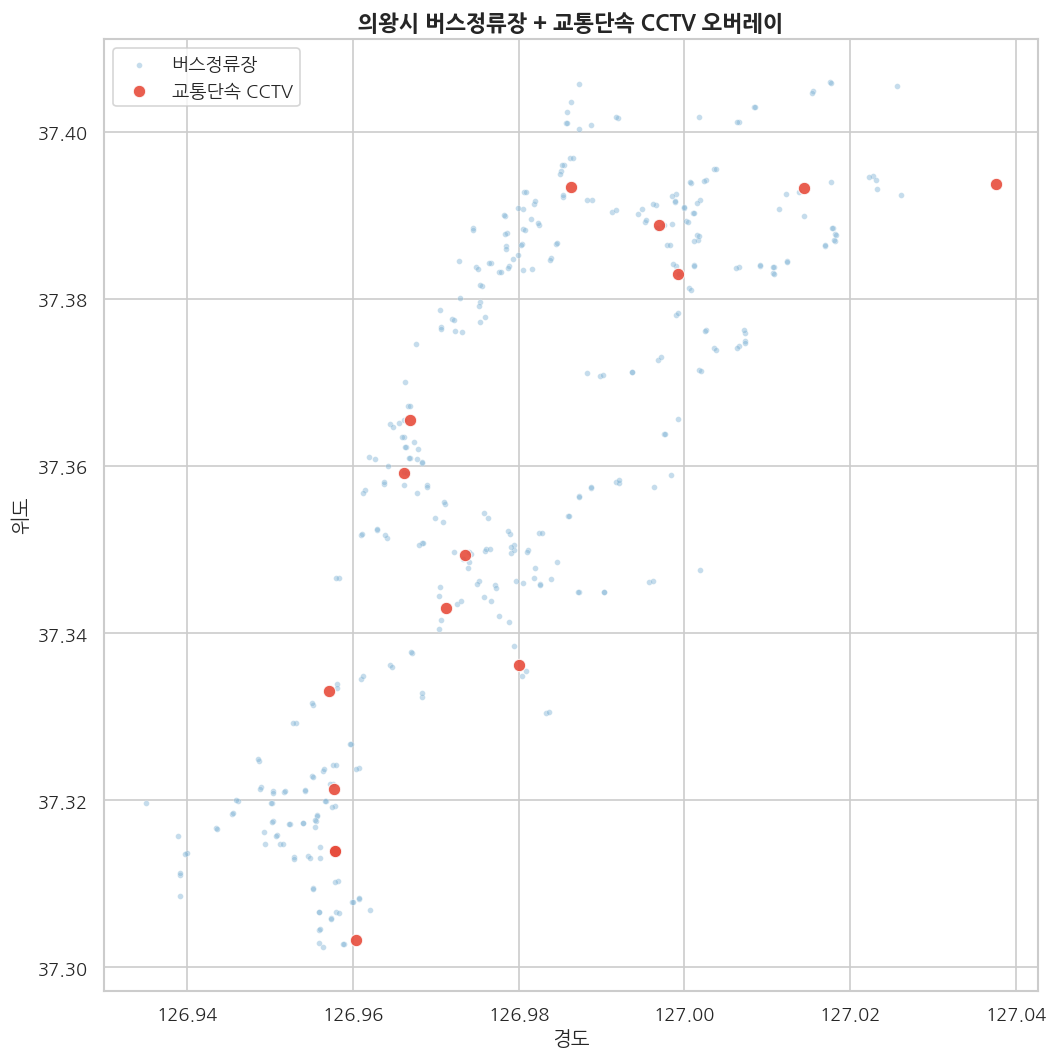

In [38]:
# 시각화 4: 버스정류장 + 교통단속 CCTV 오버레이
fig, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(
    data=bus_stop,
    x='경도',
    y='위도',
    s=12,
    alpha=0.45,
    color='#7FB3D5',
    label='버스정류장',
    ax=ax
)
sns.scatterplot(
    data=traffic_cctv,
    x='경도',
    y='위도',
    s=55,
    alpha=0.9,
    color='#E74C3C',
    label='교통단속 CCTV',
    ax=ax
)
ax.set_title('의왕시 버스정류장 + 교통단속 CCTV 오버레이', fontsize=13, fontweight='bold')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
ax.legend(loc='best')
fix_korean_font(fig)
plt.tight_layout()
plt.show()

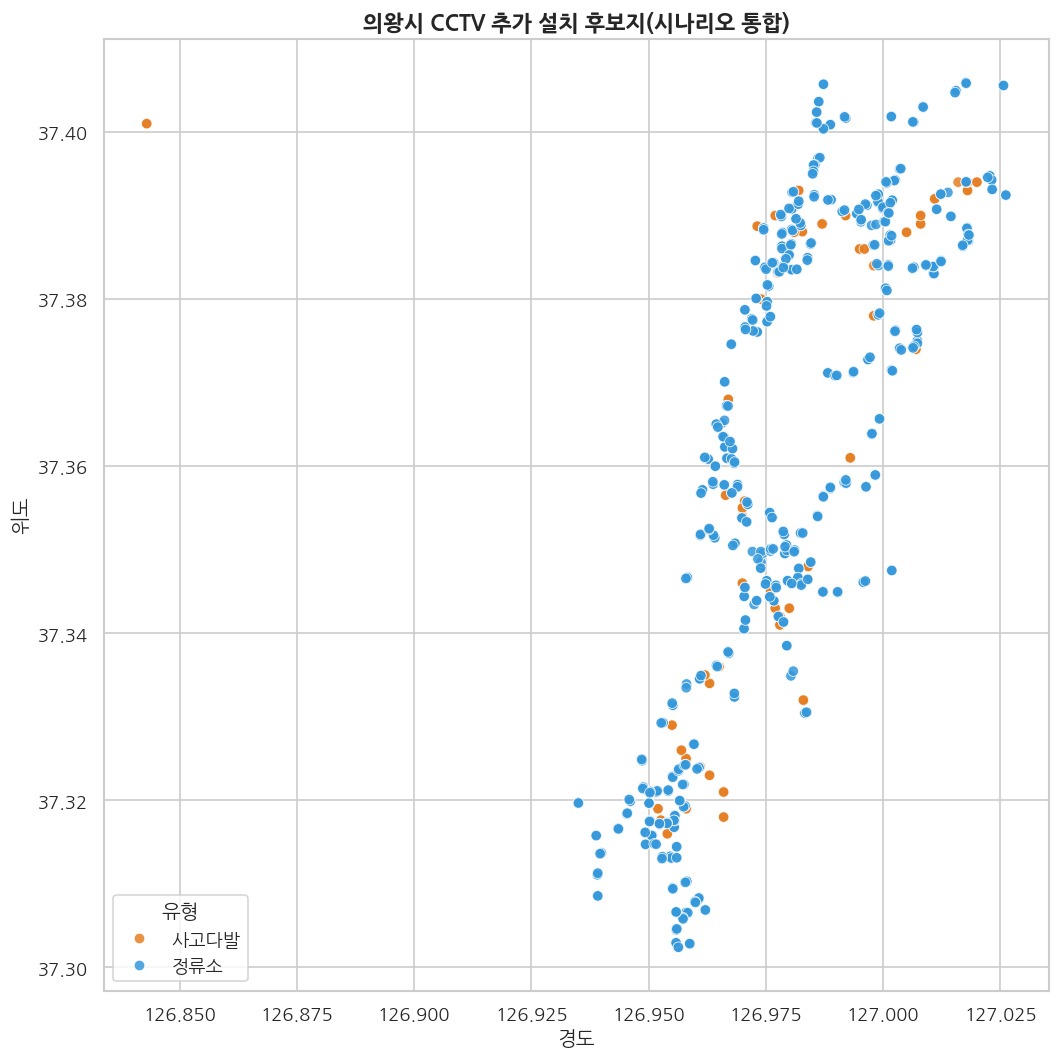

In [39]:
# 시각화 5: 최종 CCTV 추가 설치 후보지
plot_cand = candidates.copy()
plot_cand['유형'] = plot_cand['유형'].fillna('기타')

fig, ax = plt.subplots(figsize=(9, 9))
palette = {'사고다발': '#E67E22', '정류소': '#3498DB', '복합': '#8E44AD', '기타': '#95A5A6'}

sns.scatterplot(
    data=plot_cand,
    x='경도',
    y='위도',
    hue='유형',
    palette=palette,
    s=40,
    alpha=0.85,
    ax=ax
)

ax.set_title('의왕시 CCTV 추가 설치 후보지(시나리오 통합)', fontsize=13, fontweight='bold')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
ax.legend(title='유형', loc='best')
fix_korean_font(fig)
plt.tight_layout()
plt.show()

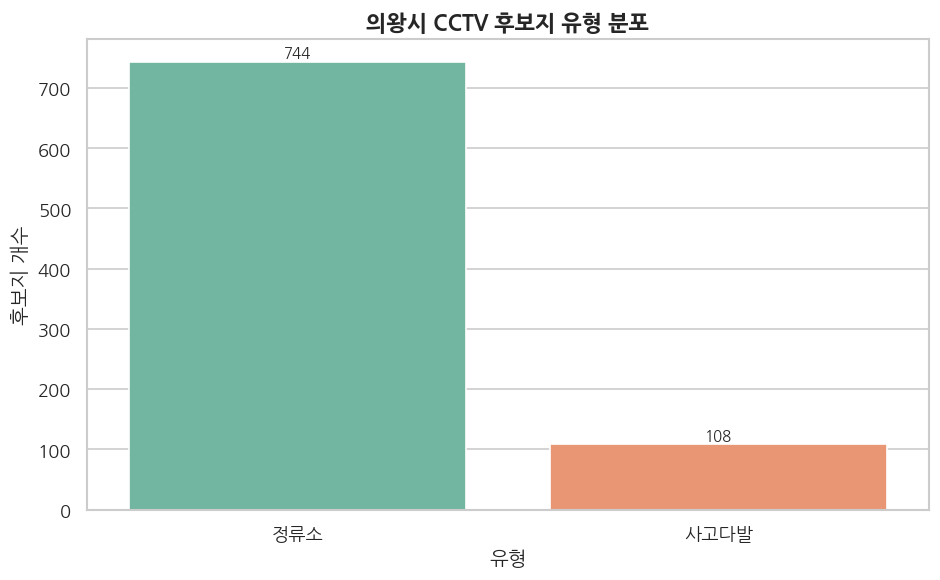

In [40]:
# 추가 시각화 1: CCTV 후보지 유형 분포
type_counts = (
    candidates['유형']
    .fillna('기타')
    .value_counts()
    .rename_axis('유형')
    .reset_index(name='개수')
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=type_counts,
    x='유형',
    y='개수',
    hue='유형',
    palette='Set2',
    legend=False,
    ax=ax,
    dodge=False,
 )
ax.set_title('의왕시 CCTV 후보지 유형 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('유형')
ax.set_ylabel('후보지 개수')
for i, v in enumerate(type_counts['개수']):
    ax.text(i, v + max(type_counts['개수']) * 0.01, f'{int(v)}', ha='center', fontsize=9)
fix_korean_font(fig)
plt.tight_layout()
plt.show()

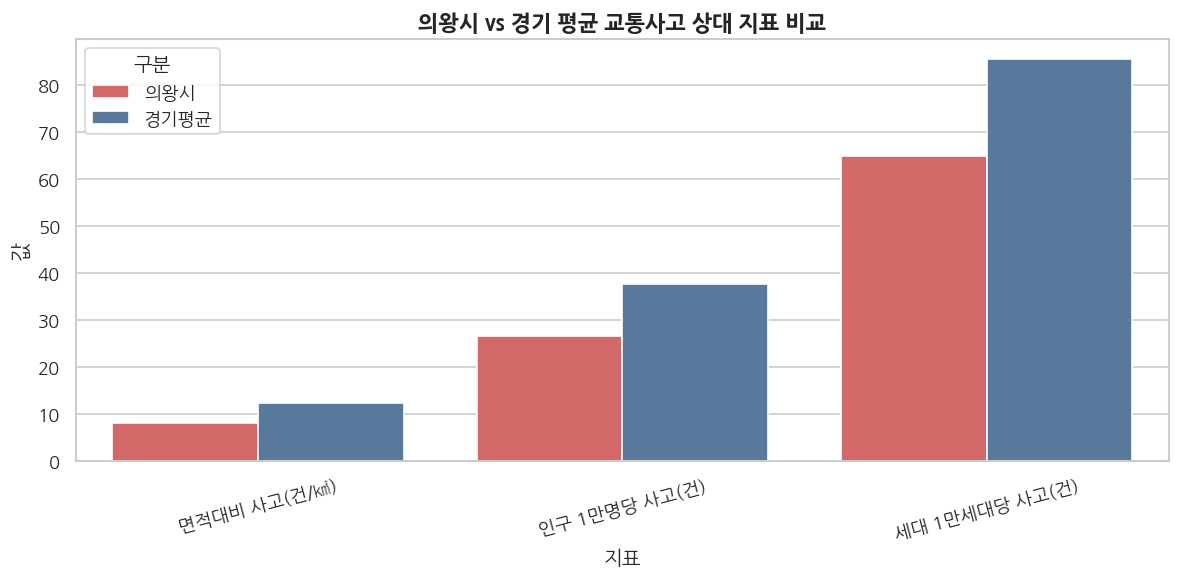

In [41]:
# 추가 시각화 2: 의왕시 vs 경기 평균(표준화 지표 비교)
metrics = [
    ('사고_면적대비(건/㎢)', '면적대비 사고(건/㎢)'),
    ('사고_인구1만명당(건)', '인구 1만명당 사고(건)'),
    ('사고_세대1만세대당(건)', '세대 1만세대당 사고(건)'),
]

g_mean = gyeonggi[[m[0] for m in metrics]].mean(numeric_only=True)
if uiwang_row.empty:
    raise ValueError('의왕시 행을 찾지 못했습니다. 데이터 파일을 확인하세요.')
u_val = uiwang_row.iloc[0][[m[0] for m in metrics]]

compare_df = pd.DataFrame({
    '지표': [m[1] for m in metrics],
    '의왕시': [float(u_val[m[0]]) for m in metrics],
    '경기평균': [float(g_mean[m[0]]) for m in metrics],
})

plot_df = compare_df.melt(id_vars='지표', var_name='구분', value_name='값')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x='지표', y='값', hue='구분', palette=['#E45756', '#4C78A8'], ax=ax)
ax.set_title('의왕시 vs 경기 평균 교통사고 상대 지표 비교', fontsize=13, fontweight='bold')
ax.set_xlabel('지표')
ax.set_ylabel('값')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='구분')
fix_korean_font(fig)
plt.tight_layout()
plt.show()

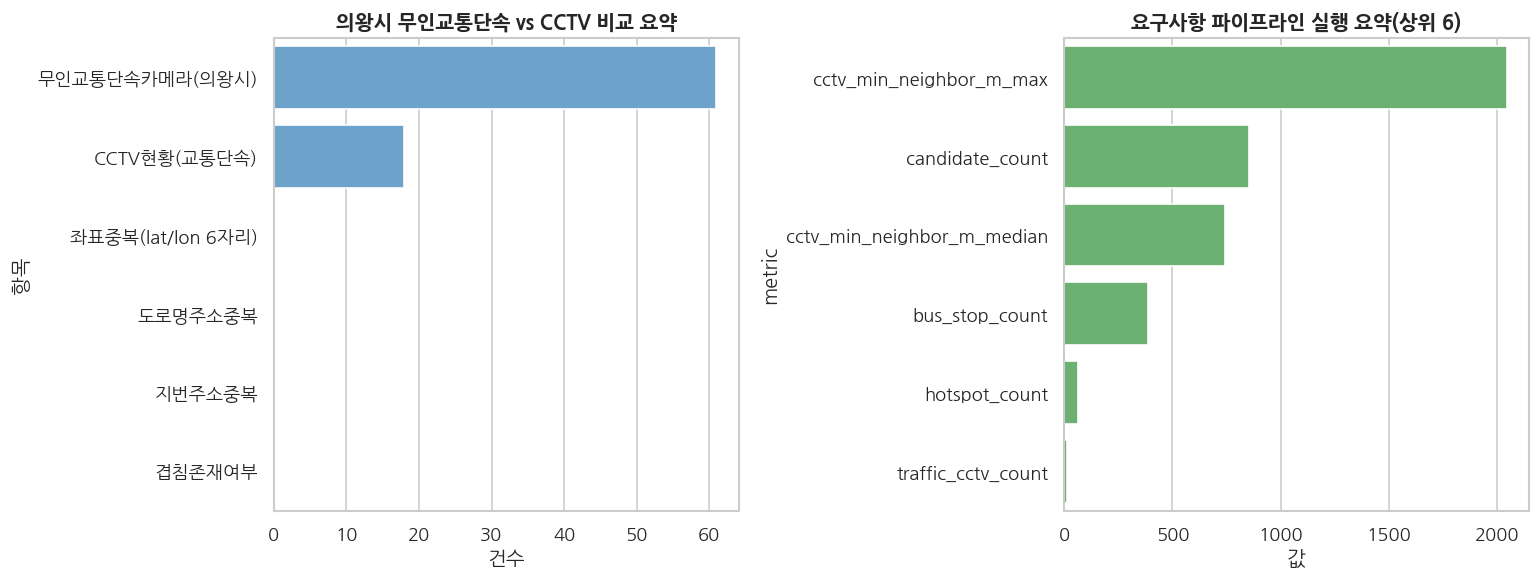

In [42]:
# 추가 시각화 3: 데이터 정합성/규모 요약
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (좌) 무인교통단속 vs CCTV 비교 요약
cmp_plot = comparison_summary.copy()
cmp_plot['건수'] = pd.to_numeric(cmp_plot['건수'], errors='coerce')
sns.barplot(data=cmp_plot, y='항목', x='건수', color='#5DA5DA', ax=axes[0])
axes[0].set_title('의왕시 무인교통단속 vs CCTV 비교 요약', fontsize=12, fontweight='bold')
axes[0].set_xlabel('건수')
axes[0].set_ylabel('항목')

# (우) 파이프라인 실행 요약 metric
run_plot = run_summary.copy()
run_plot['value'] = pd.to_numeric(run_plot['value'], errors='coerce')
top_metrics = run_plot.sort_values('value', ascending=False).head(6)
sns.barplot(data=top_metrics, y='metric', x='value', color='#60BD68', ax=axes[1])
axes[1].set_title('요구사항 파이프라인 실행 요약(상위 6)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('값')
axes[1].set_ylabel('metric')

fix_korean_font(fig)
plt.tight_layout()
plt.show()